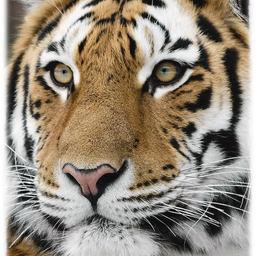

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
filename = r"C:\Users\ZiganshinShamil\Desktop\Study\Machine learning start\libraries\pillow\images\256x256_tiger.png"

with Image.open(filename) as img:
    img.load()

img


## Дискретизация сигнала 
– разбиение непрерывного сигнала на «выборки» (sampling, sampling rate)

256×256 → 128×128 → 64×64 → 8×8

Идея: берём непрерывное изображение и выбираем только определённые точки (пиксели) через равные интервалы.

Размеры оригинального изображения:  (256, 256, 3)
Sampling с шагом 2 :  (128, 128, 3)
Sampling с шагом 4 :  (64, 64, 3)
Sampling с шагом 8 :  (16, 16, 3)


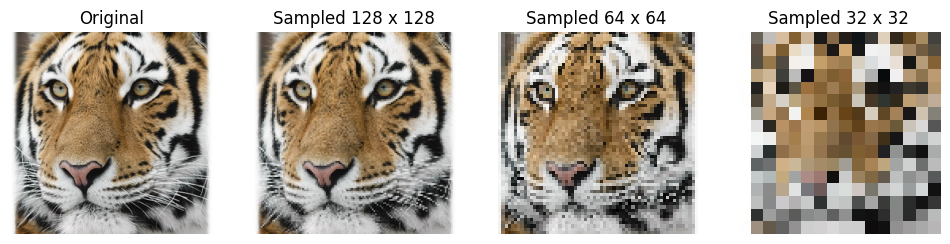

In [ ]:
#arr[start:stop:step]
#arr[строки, столбцы]

arr = np.array(img)
arr.shape

# Уменьшим изобардение до 128 x 128
step = 2
sampled_128x128 = arr[::step, ::step]
img_sampled_128x128 = Image.fromarray(sampled_128x128) # объект изображения из массива numpy

# Уменьшим изобардение до 128 x 128
step = 4
sampled_64x64 = arr[::step, ::step]
img_sampled_64x64 = Image.fromarray(sampled_64x64)

# Уменьшим изобардение до 128 x 128
step = 8
sampled_32x32 = arr[::step, ::step]
img_sampled_32x32 = Image.fromarray(sampled_32x32)

print("Размеры оригинального изображения: ", arr.shape)
print("Sampling с шагом 2 : ", sampled_128x128.shape)
print("Sampling с шагом 4 : ", sampled_64x64.shape)
print("Sampling с шагом 8 : ", sampled_32x32.shape)

plt.figure(figsize=(12, 3)) # размеры в дюймах

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray") # говорим что оно черно-белое
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2) # первые два числа говорят о том насколько мы делим нашу карту, а третья говорит в какой номер запихнуть изображение
plt.imshow(img_sampled_128x128, cmap="gray")
plt.title("Sampled 128 x 128")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_sampled_64x64, cmap="gray")
plt.title("Sampled 64 x 64")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_sampled_32x32, cmap="gray")
plt.title("Sampled 32 x 32")
plt.axis("off")

plt.show()

## Quantization (квантование)

Аналогия: У тебя есть коробка с 1000 разных мелков (исходное изображение). Тебе говорят: «Оставь только 16 самых нужных, а всё остальное рисуй ими». Ты выкидываешь 984 мелка и рисуешь картину только 16-ю. Детализация хуже, возможны пятна одного цвета, но картинка в целом узнаваема и весит в разы меньше. Это и есть квантование.


Квантование выборки – кодирование аналогового сигнала в дискретные величины (quantization)

In [75]:
# 2 Конвертируем в режим, который поддерживает квантование

# Квантование до 64 цветов
img_quantized_2 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=2)
img_quantized_3 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=3)
img_quantized_4 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=4)
img_quantized_8 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=8)
img_quantized_16 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=16)
img_quantized_256 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=256)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

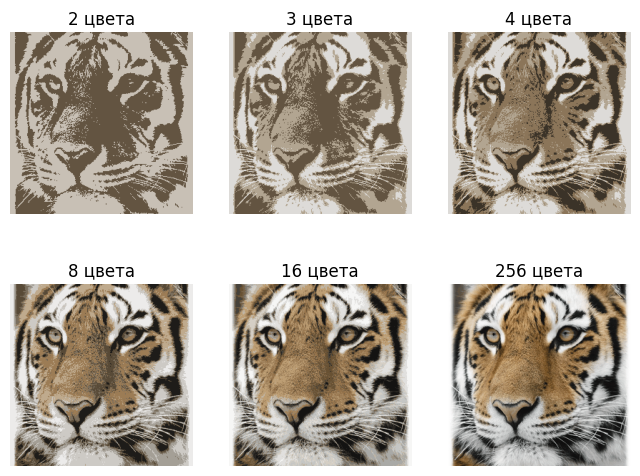

In [76]:
plt.figure(figsize=(8, 6)) # размеры в дюймах

plt.subplot(2, 3, 1)
plt.imshow(img_quantized_2)
plt.title("2 цвета")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_quantized_3)
plt.title("3 цвета")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_quantized_4)
plt.title("4 цвета")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_quantized_8)
plt.title("8 цвета")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_quantized_16)
plt.title("16 цвета")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img_quantized_256)
plt.title("256 цвета")
plt.axis("off")